<a href="https://colab.research.google.com/github/anastasiavorobeva029-commits/FMF-s-model/blob/master/Titanic_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('archive_1.zip')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


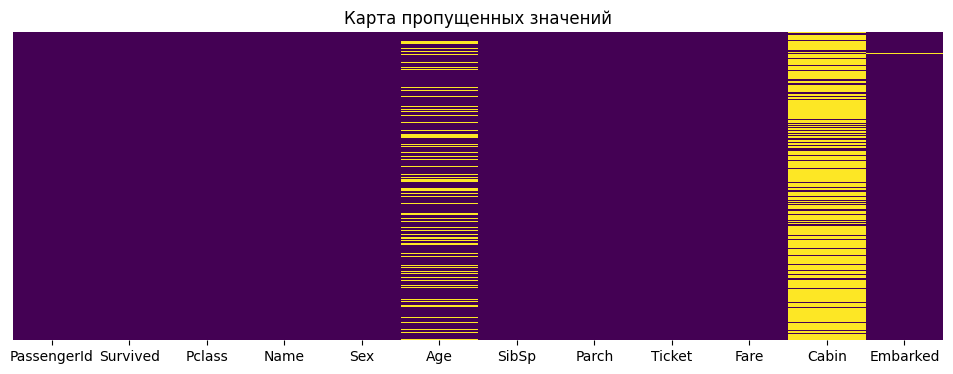

In [ ]:
plt.figure(figsize = (12,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Карта пропущенных значений')
plt.show()

In [ ]:
columns = df.select_dtypes(include=['number']).columns

for i in columns:
    median_value = df[i].median()
    df[i] = df[i].fillna(median_value)

NameError: name 'df' is not defined

In [ ]:
df['Sex'] = df['Sex'].map({'female': 'F', 'male': 'M'})
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",M,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",F,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",F,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",M,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",M,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",F,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",F,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",M,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df[['Cabin', 'Embarked']] = df[['Cabin', 'Embarked']].fillna('unknown')
df[['Cabin', 'Embarked']]


,Cabin,Embarked
0,unknown,S
1,C85,C
2,unknown,S
3,C123,S
4,unknown,S
...,...,...
886,unknown,S
887,B42,S
888,unknown,S
889,C148,C


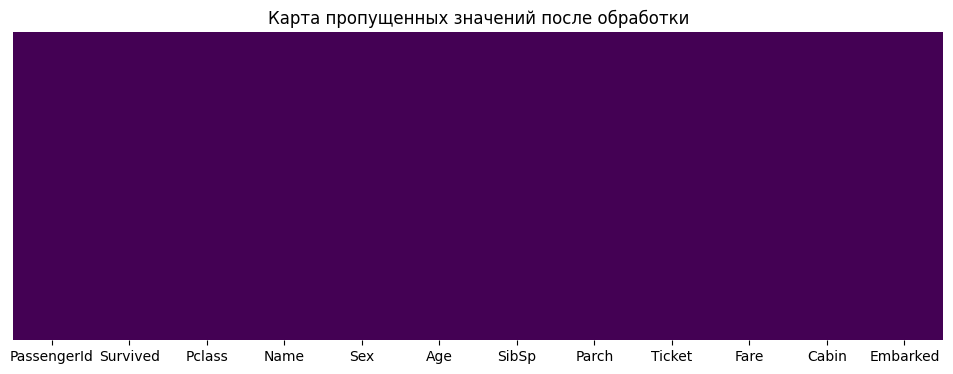

In [ ]:
plt.figure(figsize = (12,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Карта пропущенных значений после обработки')
plt.show()

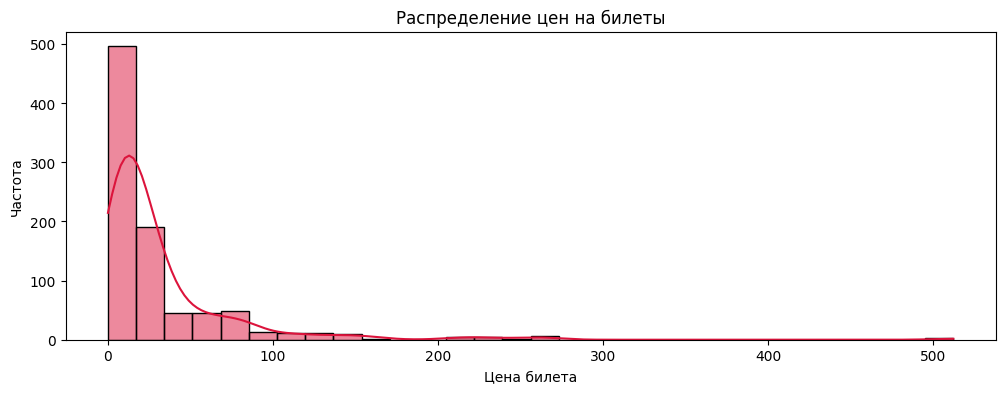

In [ ]:
plt.figure(figsize = (12,4))

sns.histplot(df['Fare'], bins=30, kde=True, color='crimson', edgecolor='black')
plt.title('Распределение цен на билеты')
plt.xlabel('Цена билета')
plt.ylabel('Частота')
plt.show()

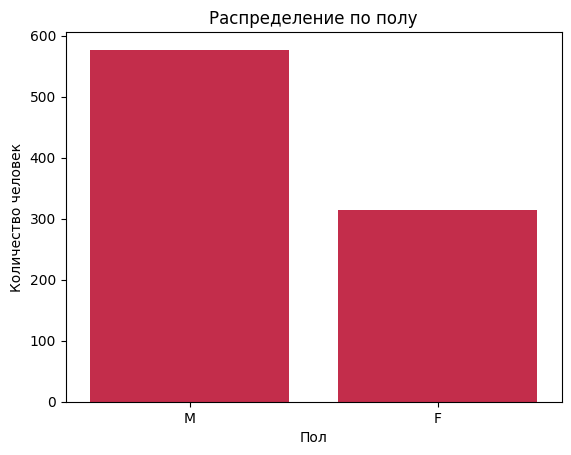

In [ ]:
sns.countplot(x = 'Sex', data = df, color='crimson')

plt.title('Распределение по полу')
plt.xlabel('Пол')
plt.ylabel('Количество человек')
plt.show()

In [ ]:
count_of_sex = df['Sex'].value_counts()
count_of_sex

,count
Sex,
M,577
F,314


/tmp/ipython-input-2693755527.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Sex', y='Fare', data=df, palette='magma', alpha=0.5)


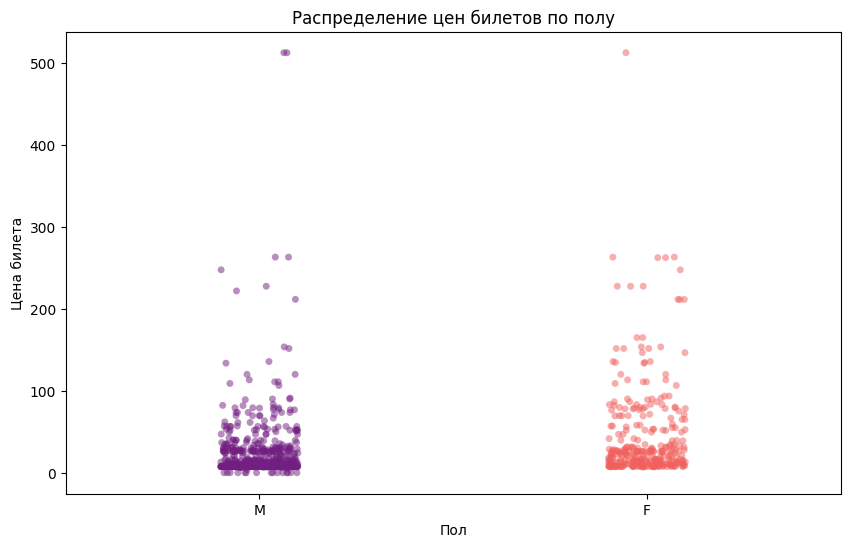

In [ ]:
plt.figure(figsize=(10, 6))

# stripplot — это идеальный «точечный» график для категорий
sns.stripplot(x='Sex', y='Fare', data=df, palette='magma', alpha=0.5)

plt.title('Распределение цен билетов по полу')
plt.xlabel('Пол')
plt.ylabel('Цена билета')
plt.show()

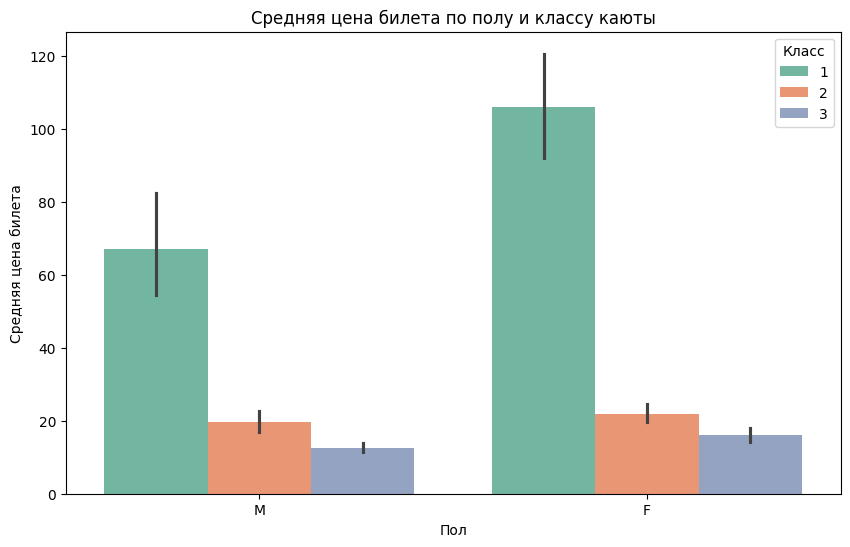

In [ ]:
plt.figure(figsize=(10, 6))

# x — пол, y — цена, hue — класс (разделит столбики цветом)
sns.barplot(x='Sex', y='Fare', hue='Pclass', data=df, palette='Set2')

plt.title('Средняя цена билета по полу и классу каюты')
plt.xlabel('Пол')
plt.ylabel('Средняя цена билета')
plt.legend(title='Класс')
plt.show()

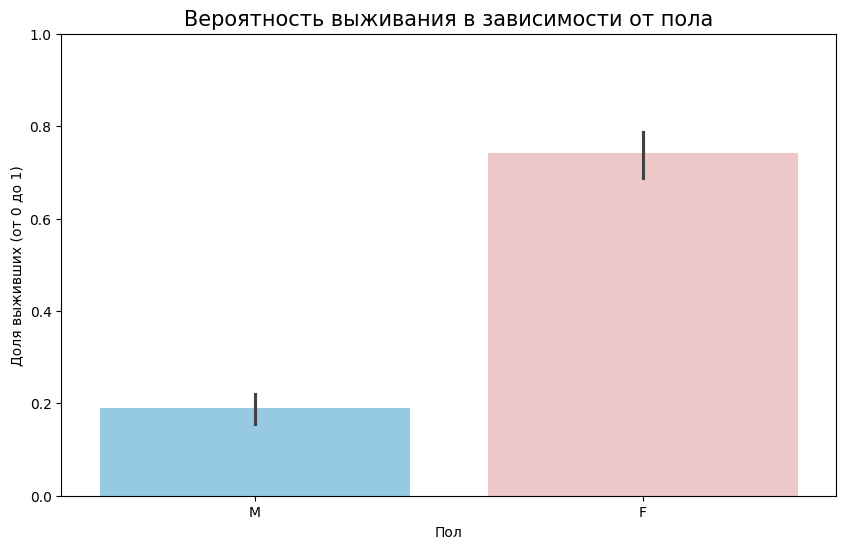

In [ ]:
pink_blue = ["#89CFF0", "#F4C2C2"]

plt.figure(figsize=(10, 6))

# Добавляем hue='Sex', чтобы цвета применились именно к мужчине/женщине
sns.barplot(x='Sex', y='Survived', data=df, palette=pink_blue, hue='Sex', legend=False)

plt.title('Вероятность выживания в зависимости от пола', fontsize=15)
plt.xlabel('Пол')
plt.ylabel('Доля выживших (от 0 до 1)')
plt.ylim(0, 1) # Устанавливаем лимит, так как это проценты
plt.show()

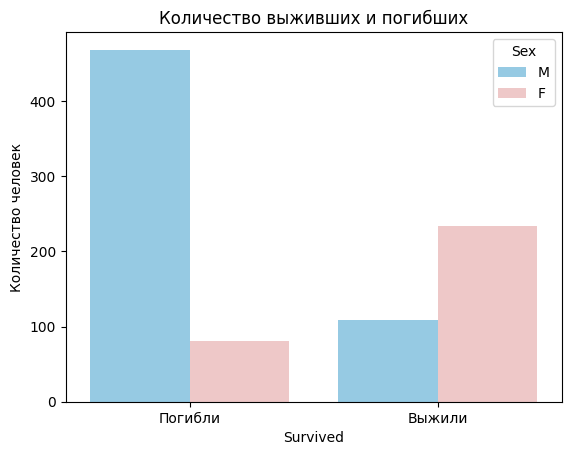

In [ ]:
sns.countplot(x='Survived', hue='Sex', data=df, palette=pink_blue)

plt.title('Количество выживших и погибших')
plt.xticks([0, 1], ['Погибли', 'Выжили']) # Меняем подписи 0 и 1 на слова
plt.ylabel('Количество человек')
plt.show()

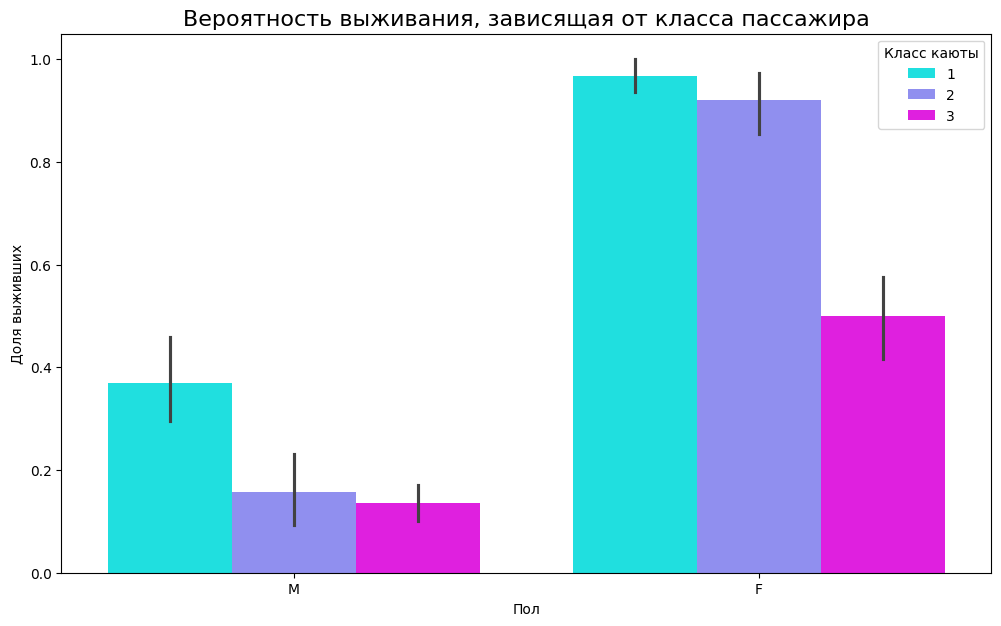

In [ ]:
plt.figure(figsize=(12, 7))

sns.barplot(x='Sex', y='Survived', hue='Pclass', data=df, palette='cool')

plt.title('Вероятность выживания, зависящая от класса пассажира', fontsize=16)
plt.ylabel('Доля выживших')
plt.xlabel('Пол')
plt.legend(title='Класс каюты')
plt.show()

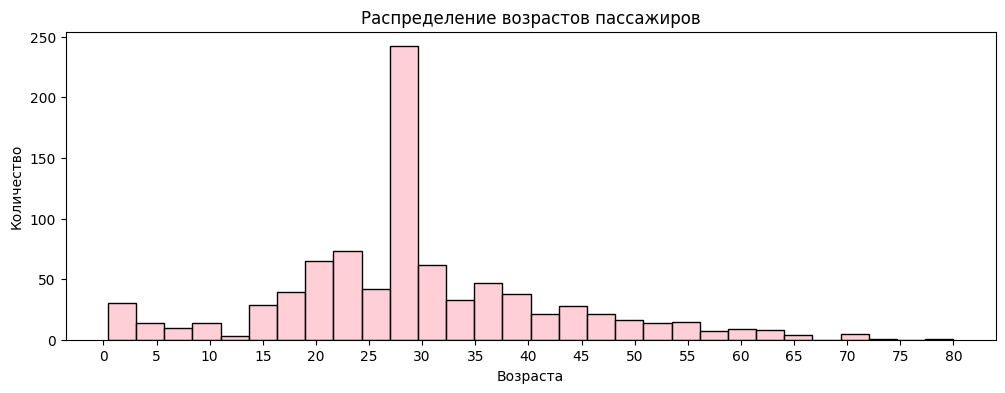

In [ ]:
plt.figure(figsize = (12,4))

sns.histplot(df['Age'], bins=30, color='pink', edgecolor='black', stat="count", kde=False)
plt.xticks(np.arange(0, 81, 5))
plt.title('Распределение возрастов пассажиров')
plt.xlabel('Возраста')
plt.ylabel('Количество')
plt.show()

In [ ]:
age_summary = df.groupby(['Survived', 'Sex'])['Age'].mean().unstack()
print(round(age_summary), 1)

Sex          F     M
Survived            
0         26.0  31.0
1         29.0  27.0 1


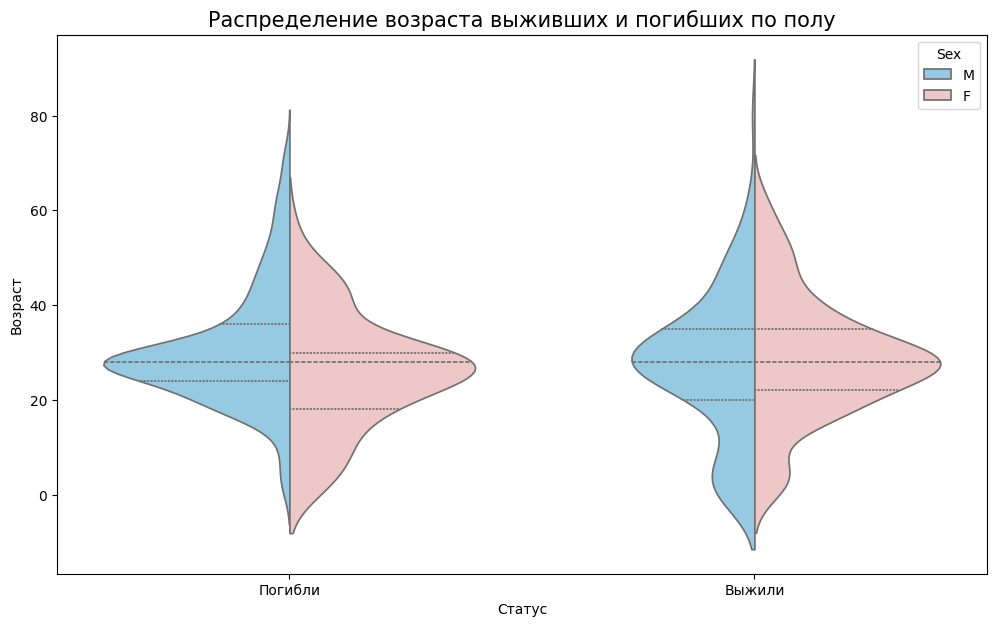

In [ ]:
plt.figure(figsize=(12, 7))

# x — выживаемость, y — возраст, hue — пол
sns.violinplot(x='Survived', y='Age', hue='Sex', data=df,
               palette=pink_blue, split=True, inner="quart")

plt.title('Распределение возраста выживших и погибших по полу', fontsize=15)
plt.xticks([0, 1], ['Погибли', 'Выжили'])
plt.xlabel('Статус')
plt.ylabel('Возраст')
plt.show()

1. Спасение детей
На правой части графика (Выжили) у голубой половины (мужчины) виден отчетливый «хвост» или расширение в нижней части — в районе 0–10 лет. Это наглядно подтверждает правило «сначала дети»: маленькие мальчики имели гораздо больше шансов спастись, чем мужчины среднего возраста.

2. Смертность мужчин трудоспособного возраста
В колонке Погибли голубая «скрипка» максимально раздута в диапазоне от 20 до 40 лет. Это говорит о том, что основную массу погибших составили молодые мужчины. У выживших мужчин (справа) эта часть, наоборот, гораздо уже.

3. Распределение у женщин
У женщин (F, розовый цвет) распределение в обеих группах (выжившие/погибшие) более равномерное и «плавное».

Заметно, что средний возраст выживших женщин (пунктирная линия внутри розовой области справа) находится в районе 25–30 лет.

У выживших женщин также виден подъем в области детей, но он менее акцентирован, чем у мальчиков, так как общая выживаемость женщин была выше во всех возрастах.

4. Пожилые пассажиры
Мы видим «острые шпили» уходящие вверх к 80 годам.

В группе выживших есть очень тонкий след в районе 80 лет у мужчин — это был знаменитый выживший пожилой пассажир.

Однако большинство пожилых людей (и мужчин, и женщин) сосредоточено в левой части («Погибли»), так как им было труднее всего в условиях катастрофы.

Что значат линии внутри?
Центральная пунктирная линия: Это медиана (средний возраст группы).

Две крайние мелкие линии: Это квартили (показывают, где сосредоточены 50% всех людей в этой группе).

Этот график отлично дополняет ваш предыдущий анализ по ценам, показывая, что судьба пассажиров зависела не только от кошелька и пола, но и от возраста.

In [ ]:
df_numeric = df.copy()

# Преобразуем пол в числа для корреляции
df_numeric['Sex'] = df_numeric['Sex'].map({'M': 0, 'F': 1, 'male': 0, 'female': 1})

# Считаем корреляцию только для числовых столбцов
corr = df_numeric.select_dtypes(include=['number']).corr()

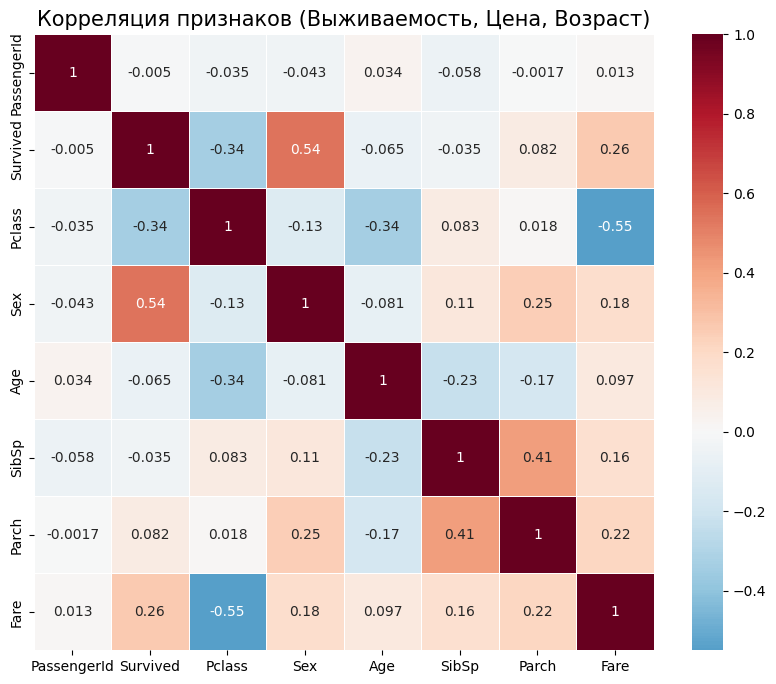

In [ ]:
plt.figure(figsize=(10, 8))

# annot=True добавит цифры в квадраты
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, linewidths=0.5)

plt.title('Корреляция признаков (Выживаемость, Цена, Возраст)', fontsize=15)
plt.show()

Гендер: Быть женщиной — самый важный фактор.

Деньги/Статус: Быть в 1-м классе или иметь дорогой билет.

Возраст: Дети имели приоритет (что видно на графиках, но скрыто в общей корреляции).